# Classification Models: Predicting Stock Movement Direction

This notebook builds a daily classification dataset from the merged NewsAPI + yFinance data, then trains and evaluates three classification models.

**Goal:** predict whether a stock's next daily return is positive or negative using stock features, sentiment features, and news volume features.

Target:
- `1` = stock moved up (`Return_1D > 0`)
- `0` = stock stayed flat or moved down (`Return_1D <= 0`)


## 1. Import Libraries

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## 2. Set File Paths

In [5]:
PROJECT_ROOT = Path.cwd().parent

INPUT_PATH = PROJECT_ROOT / "processed_data" / "cleaned_merged" / "all_companies_merged_articles_stock_clean.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = PROJECT_ROOT / "figures"

OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Input path exists:", INPUT_PATH.exists())
print("Input path:", INPUT_PATH)

Project root: c:\Users\elias\Desktop\DS3010_FinalProject
Input path exists: True
Input path: c:\Users\elias\Desktop\DS3010_FinalProject\processed_data\cleaned_merged\all_companies_merged_articles_stock_clean.csv


## 3. Load the Merged Dataset

In [6]:
df = pd.read_csv(INPUT_PATH)

df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Keep rows needed for classification
df = df.dropna(subset=["ticker", "date", "Return_1D", "sentiment_score", "sentiment_label"])

print("Rows:", len(df))
print("Columns:", df.shape[1])
df.head()

Rows: 1048
Columns: 24


,article_id,ticker,published_at,date,source_name,author,title,description,content,content_truncated,...,High,Low,Close,Volume,Return_1D,MA_5,MA_21,MA_126,MA_252,Volatility_21
0,0,AAPL,2026-03-31T19:34:20Z,2026-03-31,MacRumors,Juli Clover,OpenAI Brings ChatGPT to CarPlay for Hands-Fre...,OpenAI has updated ChatGPT with support for Ca...,OpenAI has updated ChatGPT with support for Ca...,True,...,255.479996,247.100006,253.789993,49598100,0.029031,250.945999,254.439047,264.136938,238.680955,0.012184
1,1,AAPL,2026-03-31T19:35:36Z,2026-03-31,TechCrunch,Amanda Silberling,Meta was finally held accountable for harming ...,Meta faces thousands more court cases while Co...,Meta lost a lawsuit against the state of New M...,True,...,255.479996,247.100006,253.789993,49598100,0.029031,250.945999,254.439047,264.136938,238.680955,0.012184
2,2,AAPL,2026-03-31T19:40:00Z,2026-03-31,Empire of The Kop,Empire of the Kop,Liverpool given green-light to complete £56.7m...,Castello Lukeba will be available on the marke...,Castello Lukeba will be available on the marke...,True,...,255.479996,247.100006,253.789993,49598100,0.029031,250.945999,254.439047,264.136938,238.680955,0.012184
3,3,AAPL,2026-03-31T19:45:22Z,2026-03-31,ABC News (AU),Audrey Courty,Live: Iranian president says Tehran willing to...,"Iran has the ""necessary will"" to end the war w...","As noted earlier, Iranian President Masoud Pez...",True,...,255.479996,247.100006,253.789993,49598100,0.029031,250.945999,254.439047,264.136938,238.680955,0.012184
4,4,AAPL,2026-03-31T19:45:48Z,2026-03-31,ZDNet,Kayla Solino,The Apple Pencil alternative I use daily is on...,ESR's Geo Digital Pencil is on sale for under ...,Kayla Solino/ZDNET\r\nFollow ZDNET: Add us as ...,True,...,255.479996,247.100006,253.789993,49598100,0.029031,250.945999,254.439047,264.136938,238.680955,0.012184


## 4. Build Daily Classification Dataset

The raw merged dataset has multiple news articles per stock per day. For modeling, we aggregate it to one row per `ticker` and `date`.

In [7]:
def build_daily_classification_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Binary columns for sentiment labels
    df["is_positive"] = (df["sentiment_label"] == "positive").astype(int)
    df["is_neutral"] = (df["sentiment_label"] == "neutral").astype(int)
    df["is_negative"] = (df["sentiment_label"] == "negative").astype(int)

    daily_df = (
        df.groupby(["ticker", "date"], as_index=False)
        .agg(
            # Target source and stock features
            Return_1D=("Return_1D", "first"),
            Open=("Open", "first"),
            High=("High", "first"),
            Low=("Low", "first"),
            Close=("Close", "first"),
            Volume=("Volume", "first"),
            MA_5=("MA_5", "first"),
            MA_21=("MA_21", "first"),
            MA_126=("MA_126", "first"),
            MA_252=("MA_252", "first"),
            Volatility_21=("Volatility_21", "first"),

            # Sentiment features
            sentiment_mean=("sentiment_score", "mean"),
            sentiment_median=("sentiment_score", "median"),
            sentiment_std=("sentiment_score", "std"),
            sentiment_min=("sentiment_score", "min"),
            sentiment_max=("sentiment_score", "max"),

            # News volume features
            article_count=("article_id", "count"),
            unique_sources=("source_name", "nunique"),
            truncated_articles=("content_truncated", "sum"),

            # Sentiment label counts
            positive_count=("is_positive", "sum"),
            neutral_count=("is_neutral", "sum"),
            negative_count=("is_negative", "sum"),
        )
        .sort_values(["ticker", "date"])
        .reset_index(drop=True)
    )

    # Standard deviation is NaN when there is only one article for a stock/day
    daily_df["sentiment_std"] = daily_df["sentiment_std"].fillna(0)

    # Ratios normalize counts by number of articles
    daily_df["positive_ratio"] = daily_df["positive_count"] / daily_df["article_count"]
    daily_df["neutral_ratio"] = daily_df["neutral_count"] / daily_df["article_count"]
    daily_df["negative_ratio"] = daily_df["negative_count"] / daily_df["article_count"]
    daily_df["truncated_ratio"] = daily_df["truncated_articles"] / daily_df["article_count"]

    # Classification target
    daily_df["target_direction"] = (daily_df["Return_1D"] > 0).astype(int)

    return daily_df

daily_df = build_daily_classification_dataset(df)

print("Daily rows:", len(daily_df))
daily_df.head()

Daily rows: 58


,ticker,date,Return_1D,Open,High,Low,Close,Volume,MA_5,MA_21,...,unique_sources,truncated_articles,positive_count,neutral_count,negative_count,positive_ratio,neutral_ratio,negative_ratio,truncated_ratio,target_direction
0,AAPL,2026-03-31,0.029031,247.910004,255.479996,247.100006,253.789993,49598100,250.945999,254.439047,...,65,95,52,26,20,0.530612,0.265306,0.204082,0.969388,1
1,AMZN,2026-03-31,0.036427,204.850006,210.279999,204.139999,208.270004,58470100,205.562000,210.071429,...,51,99,76,13,11,0.760000,0.130000,0.110000,0.990000,1
2,AVGO,2026-03-23,0.040825,318.000000,326.480011,314.929993,322.510010,27369200,317.489307,325.344026,...,6,8,6,2,0,0.750000,0.250000,0.000000,1.000000,1
3,AVGO,2026-03-24,-0.013085,320.000000,324.399994,314.839996,318.290009,19799000,317.019830,324.803146,...,13,16,8,3,5,0.500000,0.187500,0.312500,1.000000,0
4,AVGO,2026-03-25,0.001634,322.589996,324.299988,316.720001,318.809998,19900000,317.728101,324.517497,...,10,10,8,1,1,0.800000,0.100000,0.100000,1.000000,1


## 5. Check Class Balance

This shows whether the target has a reasonable split between up days and down/flat days.

In [8]:
class_counts = daily_df["target_direction"].value_counts().sort_index()
class_percent = daily_df["target_direction"].value_counts(normalize=True).sort_index() * 100

balance_df = pd.DataFrame({
    "class_label": ["Down/Flat (0)", "Up (1)"],
    "count": class_counts.values,
    "percent": class_percent.round(2).values
})

balance_df

,class_label,count,percent
0,Down/Flat (0),25,43.1
1,Up (1),33,56.9


## 6. Prepare Features

We use stock features, sentiment features, news volume features, and ticker dummy variables.

In [9]:
def prepare_features(daily_df: pd.DataFrame):
    feature_cols = [
        "ticker",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "MA_5",
        "MA_21",
        "MA_126",
        "MA_252",
        "Volatility_21",
        "sentiment_mean",
        "sentiment_median",
        "sentiment_std",
        "sentiment_min",
        "sentiment_max",
        "article_count",
        "unique_sources",
        "truncated_articles",
        "positive_count",
        "neutral_count",
        "negative_count",
        "positive_ratio",
        "neutral_ratio",
        "negative_ratio",
        "truncated_ratio",
    ]

    X = daily_df[feature_cols].copy()
    y = daily_df["target_direction"].copy()

    # Convert ticker into dummy variables
    X = pd.get_dummies(X, columns=["ticker"], drop_first=True)

    # Fill missing numeric values
    X = X.fillna(X.median(numeric_only=True))

    return X, y

X, y = prepare_features(daily_df)

print("Feature shape:", X.shape)
X.head()

Feature shape: (58, 33)


,Open,High,Low,Close,Volume,MA_5,MA_21,MA_126,MA_252,Volatility_21,...,negative_ratio,truncated_ratio,ticker_AMZN,ticker_AVGO,ticker_BRK-B,ticker_GOOG,ticker_GOOGL,ticker_META,ticker_MSFT,ticker_NVDA
0,247.910004,255.479996,247.100006,253.789993,49598100,250.945999,254.439047,264.136938,238.680955,0.012184,...,0.204082,0.969388,False,False,False,False,False,False,False,False
1,204.850006,210.279999,204.139999,208.270004,58470100,205.562000,210.071429,224.544444,218.329087,0.020917,...,0.110000,0.990000,True,False,False,False,False,False,False,False
2,318.000000,326.480011,314.929993,322.510010,27369200,317.489307,325.344026,343.815491,298.091018,0.024304,...,0.000000,1.000000,False,True,False,False,False,False,False,False
3,320.000000,324.399994,314.839996,318.290009,19799000,317.019830,324.803146,343.663545,298.599631,0.024415,...,0.312500,1.000000,False,True,False,False,False,False,False,False
4,322.589996,324.299988,316.720001,318.809998,19900000,317.728101,324.517497,343.514540,299.111921,0.024230,...,0.100000,1.000000,False,True,False,False,False,False,False,False


## 7. Train/Test Split

Because this is a small daily dataset, we use stratification so the train and test set keep similar class balance.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Train class balance:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).sort_index())

Training rows: 43
Testing rows: 15
Train class balance:
target_direction
0    0.44186
1    0.55814
Name: proportion, dtype: float64

Test class balance:
target_direction
0    0.4
1    0.6
Name: proportion, dtype: float64


## 8. Train Three Classification Models

Models:
1. Logistic Regression
2. Random Forest Classifier
3. Gradient Boosting Classifier

A dummy baseline is included for comparison, but it does not count as one of the three main models.

In [11]:
models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent", random_state=42),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
}

results = []
predictions = pd.DataFrame({
    "actual": y_test.values
}, index=y_test.index)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    predictions[name] = preds

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
    })

metrics_df = pd.DataFrame(results).sort_values("f1", ascending=False)
metrics_df

,model,accuracy,precision,recall,f1
0,Dummy Baseline,0.600000,0.600000,1.000000,0.750000
3,Gradient Boosting,0.666667,0.750000,0.666667,0.705882
1,Logistic Regression,0.533333,0.571429,0.888889,0.695652
2,Random Forest,0.533333,0.583333,0.777778,0.666667


## 9. Classification Reports

In [12]:
for name in models:
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(y_test, predictions[name], target_names=["Down/Flat", "Up"], zero_division=0))

Dummy Baseline
              precision    recall  f1-score   support

   Down/Flat       0.00      0.00      0.00         6
          Up       0.60      1.00      0.75         9

    accuracy                           0.60        15
   macro avg       0.30      0.50      0.37        15
weighted avg       0.36      0.60      0.45        15

Logistic Regression
              precision    recall  f1-score   support

   Down/Flat       0.00      0.00      0.00         6
          Up       0.57      0.89      0.70         9

    accuracy                           0.53        15
   macro avg       0.29      0.44      0.35        15
weighted avg       0.34      0.53      0.42        15

Random Forest
              precision    recall  f1-score   support

   Down/Flat       0.33      0.17      0.22         6
          Up       0.58      0.78      0.67         9

    accuracy                           0.53        15
   macro avg       0.46      0.47      0.44        15
weighted avg       0.48  

## 10. Visualize Model Performance

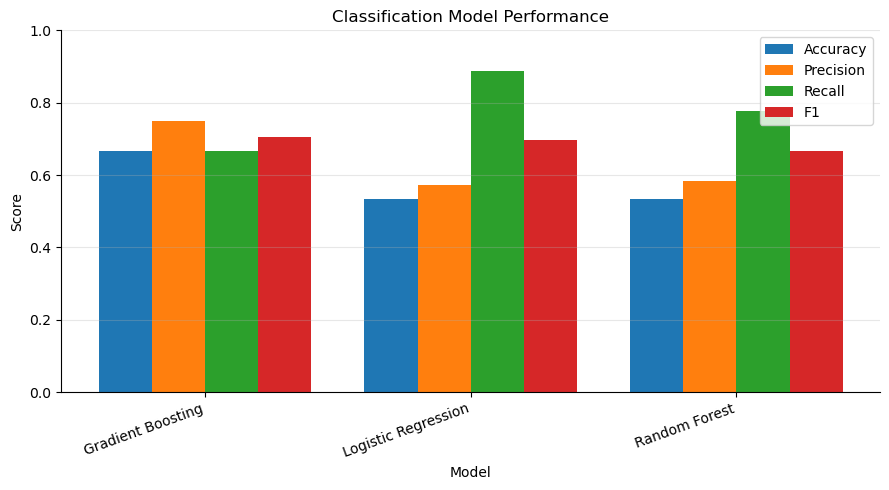

Saved figure to: c:\Users\elias\Desktop\DS3010_FinalProject\figures\classification_model_performance.png


In [13]:
plot_df = metrics_df[metrics_df["model"] != "Dummy Baseline"].copy()

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(plot_df))
width = 0.2

ax.bar(x - 1.5*width, plot_df["accuracy"], width, label="Accuracy")
ax.bar(x - 0.5*width, plot_df["precision"], width, label="Precision")
ax.bar(x + 0.5*width, plot_df["recall"], width, label="Recall")
ax.bar(x + 1.5*width, plot_df["f1"], width, label="F1")

ax.set_title("Classification Model Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"], rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

figure_path = FIGURE_DIR / "classification_model_performance.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", figure_path)

## 11. Confusion Matrix for Best Model

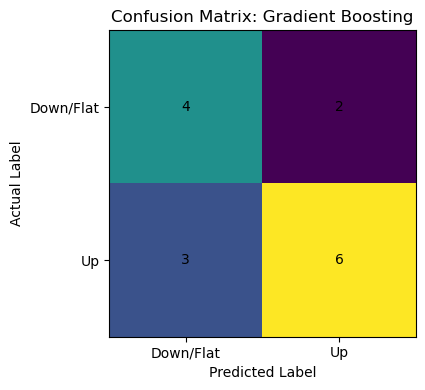

Best model: Gradient Boosting
Saved figure to: c:\Users\elias\Desktop\DS3010_FinalProject\figures\classification_confusion_matrix.png


In [14]:
best_model_name = metrics_df[metrics_df["model"] != "Dummy Baseline"].iloc[0]["model"]
best_preds = predictions[best_model_name]

cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_title(f"Confusion Matrix: {best_model_name}")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Down/Flat", "Up"])
ax.set_yticklabels(["Down/Flat", "Up"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

cm_path = FIGURE_DIR / "classification_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Best model:", best_model_name)
print("Saved figure to:", cm_path)

## 12. Save Outputs

In [15]:
# Save daily dataset, metrics, and test predictions
daily_output_path = OUTPUT_DIR / "classification_daily_dataset.csv"
metrics_output_path = OUTPUT_DIR / "classification_metrics.csv"
preds_output_path = OUTPUT_DIR / "classification_predictions.csv"

daily_df.to_csv(daily_output_path, index=False)
metrics_df.to_csv(metrics_output_path, index=False)

prediction_output = daily_df.loc[y_test.index, ["ticker", "date", "Return_1D", "target_direction"]].copy()
for name in models:
    prediction_output[f"pred_{name.lower().replace(' ', '_')}"] = predictions[name].values

prediction_output.to_csv(preds_output_path, index=False)

print("Saved:")
print(daily_output_path)
print(metrics_output_path)
print(preds_output_path)

Saved:
c:\Users\elias\Desktop\DS3010_FinalProject\outputs\classification_daily_dataset.csv
c:\Users\elias\Desktop\DS3010_FinalProject\outputs\classification_metrics.csv
c:\Users\elias\Desktop\DS3010_FinalProject\outputs\classification_predictions.csv


## 13. Short Interpretation

The classification task predicts whether each stock's daily return is positive or negative. The models use a combination of price-based indicators, rolling volatility, sentiment statistics, article volume, source diversity, and ticker identity. 

The dummy baseline is included to check whether the real models outperform simply guessing the most common class. Among the three real classification models, Gradient Boosting performed best by accuracy, but the dummy baseline remained competitive due to the small dataset and slightly imbalanced target classes. Because there are only 58 daily observations, these results should be interpreted cautiously.
